In [1]:
data_dir = '/home/mjehangir/telomere-sv-analysis/data/'

In [2]:
setwd(data_dir)

In [3]:
# Load necessary libraries
library(openxlsx)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ComplexHeatmap)
library(circlize)
library(tibble)
library(ggridges)
library(tidyverse)
library(ggplot2)
library(scales)
library(patchwork) 



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: grid

ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


circlize version 0.4.16
CRAN page: https://cran.r-project.org/package

In [78]:
# Read the telomere length CSV file into a data frame
df <- read.csv("gliomas_telomers.csv", header = TRUE)

# Set column names
#colnames(df) <- c("Sample", "Chromosome", "Value", "Other_1", "Arm")

# View the data
head(df)


,Sample_prefix,chr,final_average_TL_p75,chr_order,arm
,<chr>,<chr>,<dbl>,<int>,<chr>
1,2436A,chr1p,5221.000,1,p
2,2436A,chr1q,5051.167,1,q
3,3188,chr1p,1642.500,1,p
4,3188,chr1q,3086.500,1,q
5,3988,chr1p,2347.500,1,p
6,3988,chr1q,5083.000,1,q


In [79]:
df$final_average_TL_p75_kb <- df$final_average_TL_p75 / 1000
head(df)

,Sample_prefix,chr,final_average_TL_p75,chr_order,arm,final_average_TL_p75_kb
,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>
1,2436A,chr1p,5221.000,1,p,5.221000
2,2436A,chr1q,5051.167,1,q,5.051167
3,3188,chr1p,1642.500,1,p,1.642500
4,3188,chr1q,3086.500,1,q,3.086500
5,3988,chr1p,2347.500,1,p,2.347500
6,3988,chr1q,5083.000,1,q,5.083000


In [80]:
summary_stats <- df %>%
  summarize(mean_TL = mean(final_average_TL_p75, na.rm = TRUE),
            min_TL = min(final_average_TL_p75, na.rm = TRUE),
            max_TL = max(final_average_TL_p75, na.rm = TRUE))

summary_stats


mean_TL,min_TL,max_TL
<dbl>,<dbl>,<dbl>
5049.146,126,12829.5


Picking joint bandwidth of 632



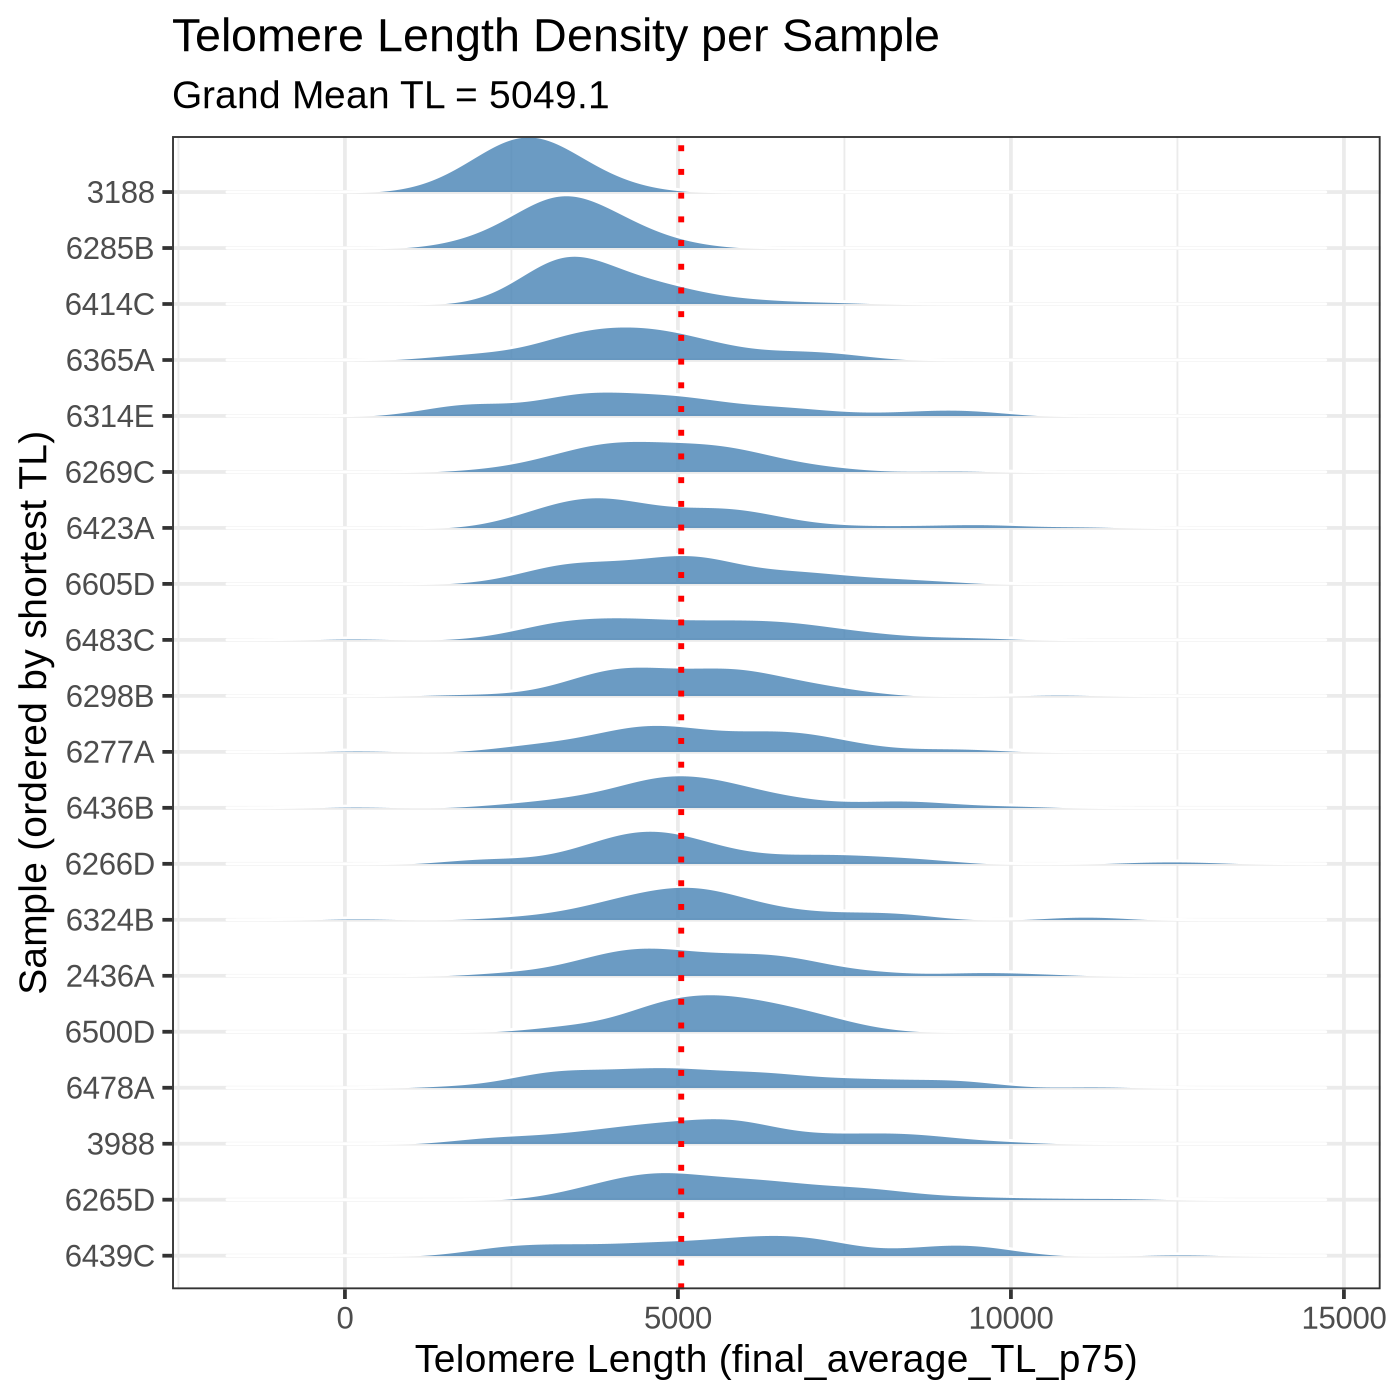

In [8]:
# Calculate mean TL per sample and reorder samples
sample_avg <- df %>%
  group_by(Sample_prefix) %>%
  summarise(mean_TL = mean(final_average_TL_p75, na.rm = TRUE)) %>%
  arrange(mean_TL)

df$Sample_prefix <- factor(df$Sample_prefix, levels = sample_avg$Sample_prefix)

# Calculate grand mean telomere length across all samples
grand_mean <- mean(df$final_average_TL_p75, na.rm = TRUE)

options(repr.plot.width = 7, repr.plot.height = 7, repr.plot.res = 200)

# Plot with grand mean vertical dotted line
p <- ggplot(df, aes(x = final_average_TL_p75, y = Sample_prefix)) +
  geom_density_ridges(scale = 1, alpha = 0.8, fill = "#4682B4", color = "white") +
  geom_vline(xintercept = grand_mean, linetype = "dotted", color = "red", size = 1) +
  scale_y_discrete(limits = rev(levels(df$Sample_prefix))) +
  labs(
    title = "Telomere Length Density per Sample",
    subtitle = paste("Grand Mean TL =", round(grand_mean, 1)),
    x = "Telomere Length (final_average_TL_p75)",
    y = "Sample (ordered by shortest TL)"
  ) +
  theme_bw(base_size = 14)
#ggsave("/home/mjehangir/telomere-sv-analysis/plots/fig3/tel_ridge_plot_by_sample.pdf",
  #     plot = p, height = 7, width = 7, dpi = 300)
p

Picking joint bandwidth of 812



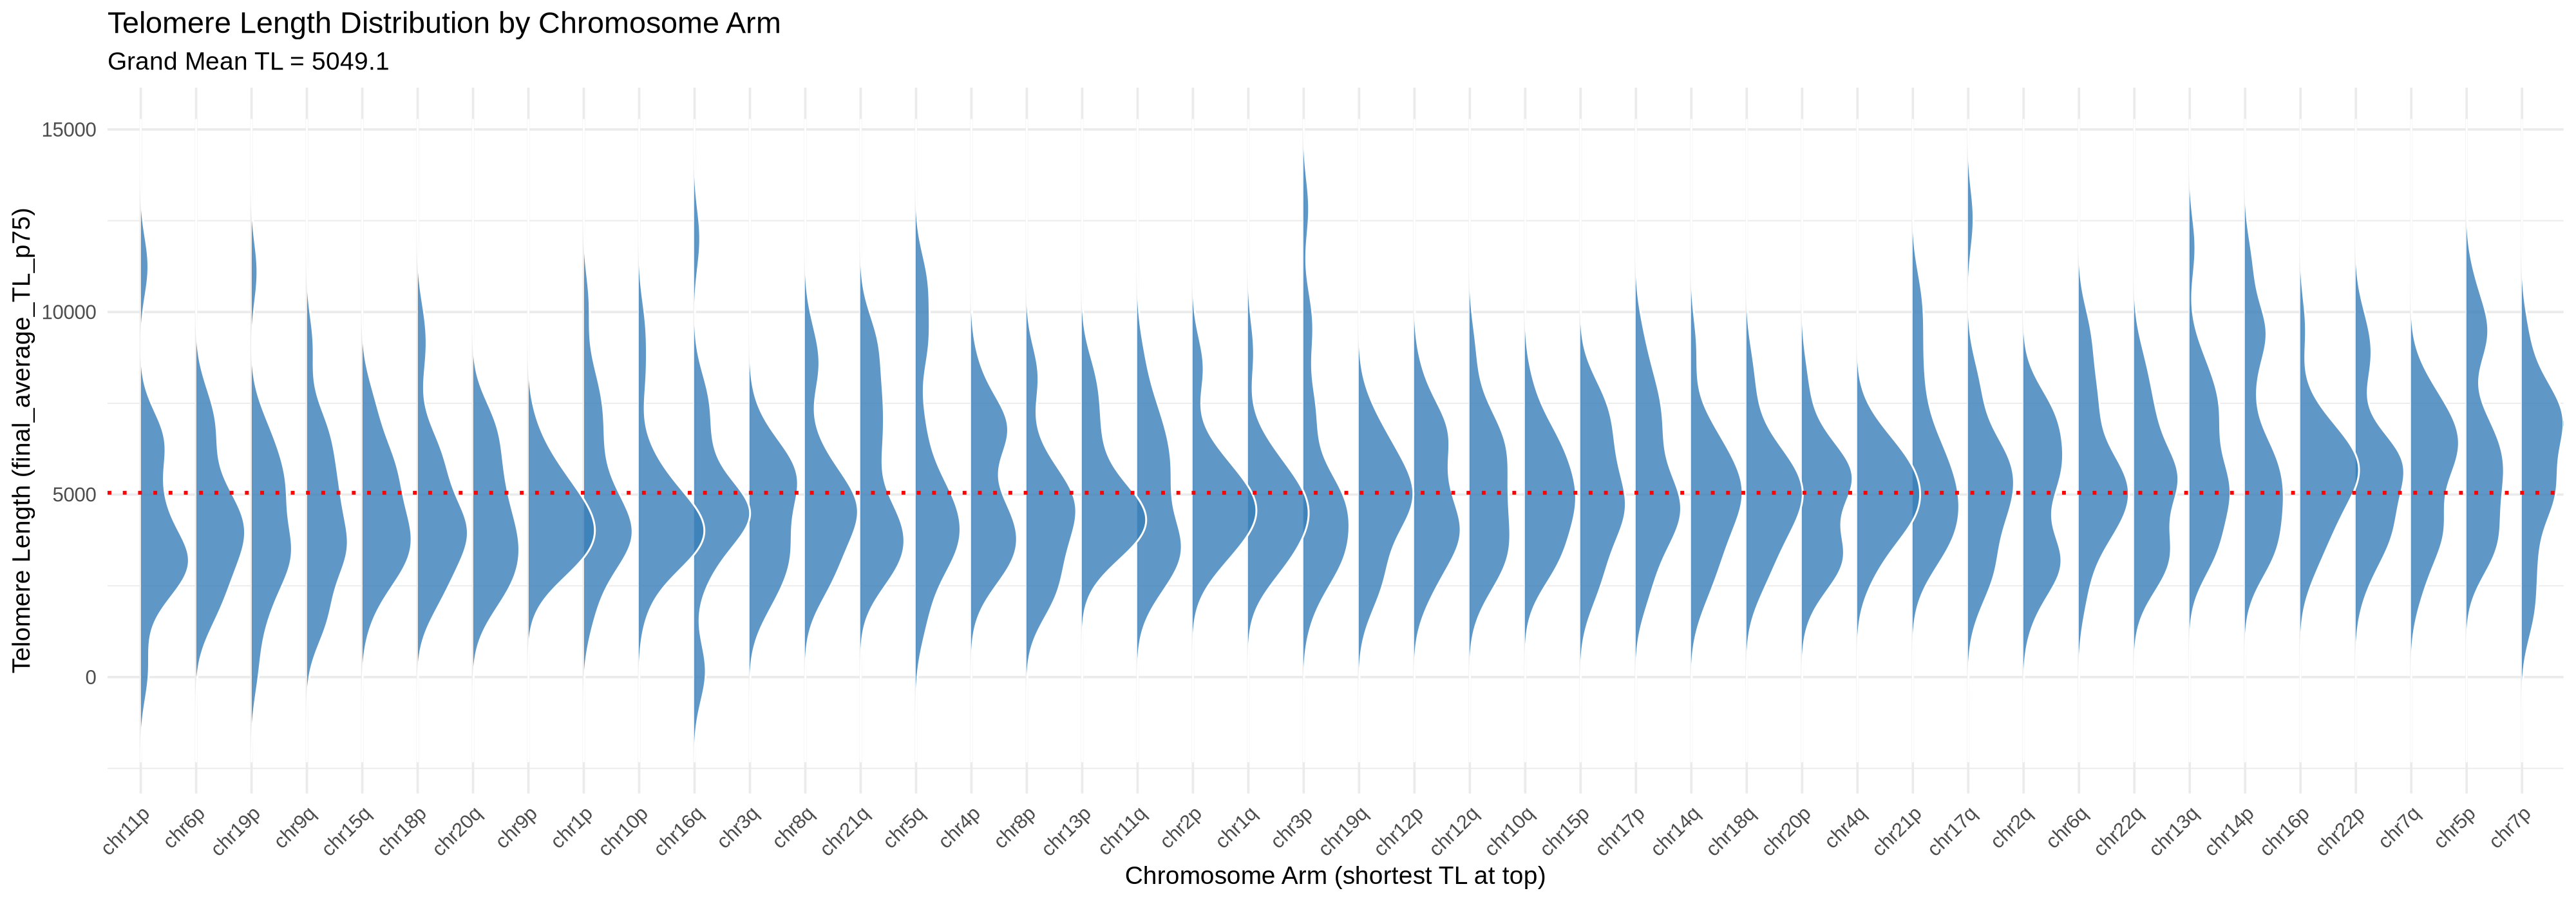

In [9]:
# Step 1: Order chr by median TL
arm_order <- df %>%
  group_by(chr) %>%
  summarise(median_TL = median(final_average_TL_p75, na.rm = TRUE)) %>%
  arrange(median_TL) %>%
  pull(chr)

df$chr <- factor(df$chr, levels = arm_order)

# Step 2: Calculate grand mean
grand_mean <- mean(df$final_average_TL_p75, na.rm = TRUE)

options(repr.plot.width = 20, repr.plot.height = 7, repr.plot.res = 200)

q <- ggplot(df, aes(x = final_average_TL_p75, y = chr)) +
  geom_density_ridges(
    scale = 1.2,
    alpha = 0.8,
    fill = "#377eb8",
    color = "white"
  ) +
  geom_vline(xintercept = grand_mean, linetype = "dotted", color = "red", size = 1) +
  labs(
    title = "Telomere Length Distribution by Chromosome Arm",
    subtitle = paste("Grand Mean TL =", round(grand_mean, 1)),
    x = "Telomere Length (final_average_TL_p75)",
    y = "Chromosome Arm (shortest TL at top)"
  ) +
  coord_flip() +
  theme_minimal(base_size = 14)+
theme(axis.text.x = element_text(angle = 45, hjust = 1))

q

Picking joint bandwidth of 812



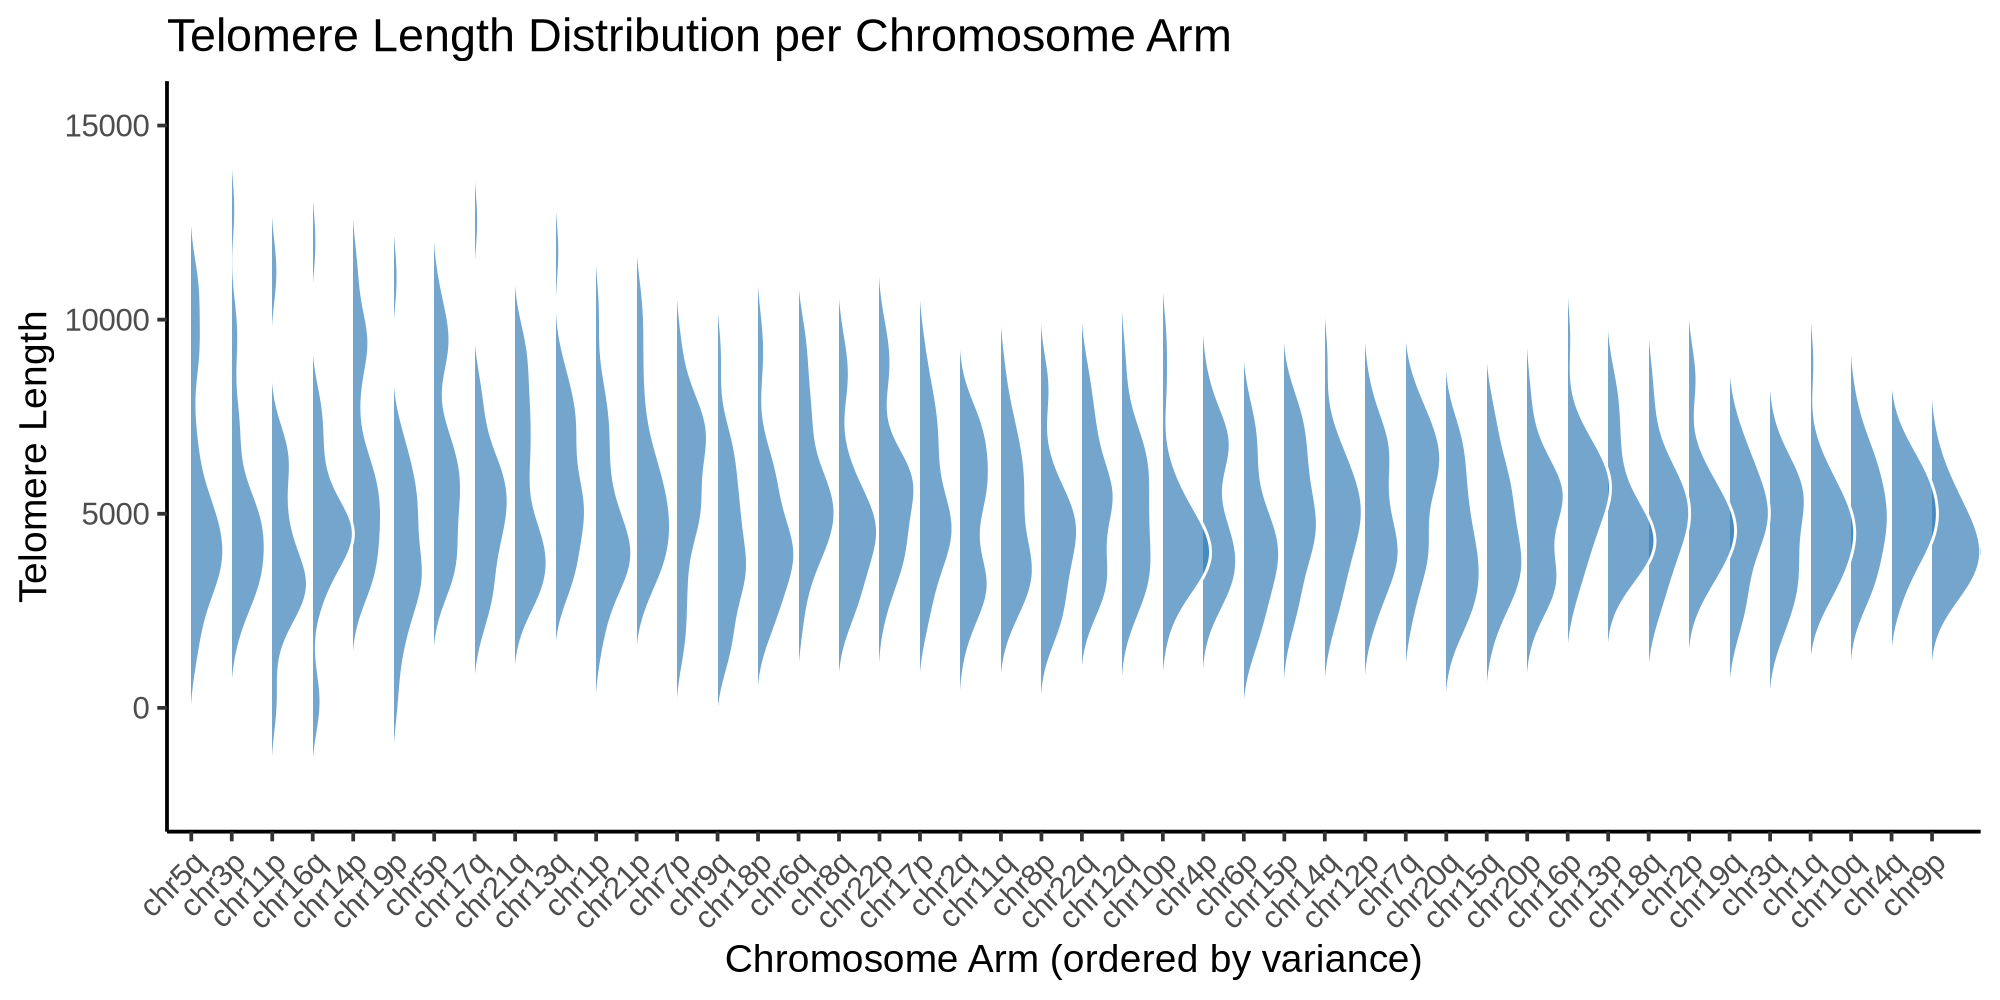

In [58]:
# 1. Calculate variance and IQR per chromosome arm
arm_stats <- df %>%
  group_by(chr) %>%
  summarise(
    variance_TL = var(final_average_TL_p75, na.rm = TRUE),
    IQR_TL = IQR(final_average_TL_p75, na.rm = TRUE),
    median_TL = median(final_average_TL_p75, na.rm = TRUE),
    n = n()
  ) %>%
  arrange(desc(variance_TL))

# 2. Order chromosome arms by variance (descending)
df$chr <- factor(df$chr, levels = arm_stats$chr)

# 3. Ridgeline plot with vertical aesthetics + flipped coordinates
options(repr.plot.width = 10, repr.plot.height = 5, repr.plot.res = 200)

p <- ggplot(df, aes(x = final_average_TL_p75, y = chr)) +
  geom_density_ridges(
    fill = "#377eb8", alpha = 0.7, color = "white", scale = 1.2
  ) +
  labs(
    title = "Telomere Length Distribution per Chromosome Arm",
    x = "Telomere Length",
    y = "Chromosome Arm (ordered by variance)"
  ) +
  theme_classic(base_size = 14) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  coord_flip()
p

In [59]:
ggsave(
  "/home/mjehangir/telomere-sv-analysis/plots/fig3/tel_ridge_plot_by_arms.pdf",
  plot = p,
  height =5,
  width = 10,
  dpi = 300
)


Picking joint bandwidth of 812

